In [1]:
# !myenv\Scripts\activate

In [2]:
# !python -m venv myenv

In [3]:
# !pip install ipykernel
# !python -m ipykernel install --user --name=myenv --display-name="Python (My GPU Venv)"

In [4]:
# !pip freeze >requirements.txt

In [5]:
# !pip install -r requirements.txt

In [6]:
import os
import torch
import numpy as np
import pandas as pd
from torch import nn
from datasets import Dataset
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns


c:\Users\Asus\Desktop\CustomEmotionDetector\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [7]:
EMOTION_MAP = { 0: "neutral", 1: "anger", 2: "disgust", 3: "fear", 4: "happiness", 5: "sadness", 6: "surprise"}

ACT_MAP = {1:'Inform', 2:'Question', 3:'Directive', 4:'Commissive'}

In [8]:
def build_master_dataset(text, emotion, act, set):
    if Path(f'Data/{set}/df_{set}.csv').exists():
        return pd.read_csv(f'Data/{set}/df_{set}.csv')
    else:
        rows = []
        with open(f'Data/{set}/{text}', 'r', encoding='utf-8') as f_text, \
        open(f'Data/{set}/{emotion}', 'r', encoding='utf-8') as f_emotion, \
        open(f'Data/{set}/{act}', 'r', encoding='utf-8') as f_act:
            for conv_id, (t_line, e_line, a_line) in enumerate(zip(f_text, f_emotion, f_act)):
                conv_text = [t.strip() for t in t_line.split('__eou__') if t.strip()]
                conv_emo = e_line.strip().split()
                conv_act = a_line.strip().split()

                if len(conv_text) == len(conv_emo) == len(conv_act) :
                    for i in range(len(conv_text)):
                        prev_conv = conv_text[i-1] if i!=0 else ""
                        rows.append(
                            {
                                'Conversation Id' : conv_id,
                                'Turn' : i,
                                'Text' : conv_text[i],
                                'Context' : prev_conv,
                                'Emotion Label' : int(conv_emo[i]),
                                'Act label' : int(conv_act[i])
                            }
                        )
                else :
                    print(f"Skipping conversation {conv_id} of {set} due to length mismatch ! Text_length : {len(conv_text)}, Emo length : {len(conv_emo)}, Act length : {len(conv_act)}")

            df = pd.DataFrame(rows)
            df.to_csv(f'Data/{set}/df_{set}.csv', index=False)
            print(f"Successfully saved {len(df)} turns to Data/{set}/df_{set}.csv")
            return df


In [9]:

train_df = build_master_dataset('dialogues_train.txt', 'dialogues_emotion_train.txt', 'dialogues_act_train.txt', 'train')
validation_df = build_master_dataset('dialogues_validation.txt', 'dialogues_emotion_validation.txt', 'dialogues_act_validation.txt', 'validation')
test_df = build_master_dataset('dialogues_test.txt', 'dialogues_emotion_test.txt', 'dialogues_act_test.txt', 'test')


In [10]:
np.unique(train_df['Act label'])

array([1, 2, 3, 4])

In [11]:
train_df.head()

,Conversation Id,Turn,Text,Context,Emotion Label,Act label
0,0,0,"Say , Jim , how about going for a few beers af...",NaN,0,3
1,0,1,You know that is tempting but is really not go...,"Say , Jim , how about going for a few beers af...",0,4
2,0,2,What do you mean ? It will help us to relax .,You know that is tempting but is really not go...,0,2
3,0,3,Do you really think so ? I don't . It will jus...,What do you mean ? It will help us to relax .,0,2
4,0,4,I guess you are right.But what shall we do ? I...,Do you really think so ? I don't . It will jus...,0,2


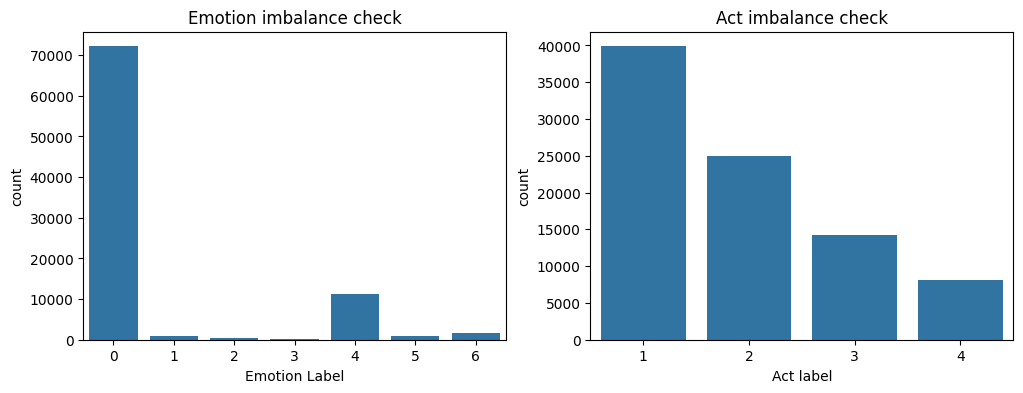

In [12]:
# 1. Check Class Distribution
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
sns.countplot(x = 'Emotion Label' , data= train_df)
plt.title('Emotion imbalance check')

plt.subplot(1,2,2)
sns.countplot(x = 'Act label' , data= train_df)
plt.title('Act imbalance check')

plt.show()


In [13]:
# Apply to all splits
for df in [train_df, validation_df, test_df]:
    
    df['Act label'] = df['Act label']-1

    # Change None type to string
    df['Context'] = df['Context'].fillna("").astype(str)
    df['Text'] = df['Text'].fillna("").astype(str)

    df['Combined Text'] = df.apply(lambda x: f"<s>{x['Context']}</s></s>{x['Text']}</s>", axis=1)

    df.drop(columns=['Context', 'Text'], inplace=True)
    # re-ordering of columns
    new_order = ['Conversation Id', 'Turn', 'Combined Text', 'Emotion Label', 'Act label']
    for i, col_name in enumerate(new_order):
        col_to_move = df.pop(col_name)
        df.insert(i, col_name, col_to_move)

In [14]:
train_df.head()

,Conversation Id,Turn,Combined Text,Emotion Label,Act label
0,0,0,"<s></s></s>Say , Jim , how about going for a f...",0,2
1,0,1,"<s>Say , Jim , how about going for a few beers...",0,3
2,0,2,<s>You know that is tempting but is really not...,0,1
3,0,3,<s>What do you mean ? It will help us to relax...,0,1
4,0,4,<s>Do you really think so ? I don't . It will ...,0,1


In [15]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [16]:
from transformers import AutoTokenizer

model_used = 'FacebookAI/roberta-base'
tokenizer = AutoTokenizer.from_pretrained(model_used)

In [17]:
def preprocessor(data):
    model_inputs = tokenizer(
        data['Combined Text'],
        max_length = 160,
        truncation = True,
        padding = False
    )
     
    model_inputs['label_emo'] = data['Emotion Label']
    model_inputs['label_act'] = data['Act label']

    return model_inputs

In [18]:
from datasets import Dataset
from transformers import DataCollatorWithPadding

# Convert to Hugging face dataset
train_ds = Dataset.from_pandas(train_df)
val_ds = Dataset.from_pandas(validation_df)
test_ds = Dataset.from_pandas(test_df)

# Tokenization
print("Tokenizing the datasets...")
tokenized_train = train_ds.map(preprocessor, batched=True)
tokenized_val = val_ds.map(preprocessor, batched=True)
tokenized_test = test_ds.map(preprocessor, batched=True)

# Dropping unnecessary columns
cols_to_remove = ['Conversation Id', 'Turn', 'Emotion Label', 'Act label']
tokenized_train = tokenized_train.remove_columns(cols_to_remove)
tokenized_val = tokenized_val.remove_columns(cols_to_remove)
tokenized_test = tokenized_test.remove_columns(cols_to_remove)

# Initialize DataCollator
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

Tokenizing the datasets...


Map: 100%|██████████| 7740/7740 [00:00<00:00, 63971.58 examples/s]


In [19]:
import torch
import torch.nn as nn
import numpy as np
import torch.nn.functional as F
from sklearn.utils.class_weight import compute_class_weight
from transformers import RobertaPreTrainedModel, RobertaModel

# emo_values = train_df['Emotion Label'].values

# raw_weights = compute_class_weight('balanced', classes=np.unique(emo_values), y=emo_values)

# emotion_weights_tensor = torch.tensor(raw_weights, dtype=torch.float32)

# print(f"Emotion weights :\n{[EMOTION_MAP[e] for e in np.unique(emo_values)]} : {emotion_weights_tensor}")


In [20]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

# Calculate counts for each class
class_counts = train_df['Emotion Label'].value_counts().sort_index().values
total_samples = len(train_df)

# Square root smoothing formula: weight = sqrt(N_total / N_class)
# Then normalized so the average weight is 1.0
smoothed_weights = np.sqrt(total_samples / class_counts)
normalized_weights = smoothed_weights / np.mean(smoothed_weights)

emotion_weights_tensor = torch.tensor(normalized_weights, dtype=torch.float32)

In [ ]:
class MultiTaskRoberta(RobertaPreTrainedModel):
    def __init__(self, config):
        super().__init__(config)
        self.roberta = RobertaModel(config=config, add_pooling_layer=True)
        
        # Hyperparameters for Focal Loss
        self.gamma = getattr(config, "focal_gamma", 2.0)
        
        # Register smoothed weights as a buffer for GPU/CPU compatibility
        if hasattr(config, "emo_weights"):
            self.register_buffer("emo_weights", torch.tensor(config.emo_weights, dtype=torch.float32))
        else:
            self.emo_weights = None

        self.emo_dropout = nn.Dropout(0.2)
        self.emo_classifier = nn.Linear(config.hidden_size, 7)

        self.act_dropout = nn.Dropout(0.2)
        self.act_classifier = nn.Linear(config.hidden_size, 4)

        self.post_init()

    def forward(self, input_ids=None, attention_mask=None, label_emo=None, label_act=None, **kwargs):
        outputs = self.roberta(input_ids, attention_mask=attention_mask)
        pooled_output = outputs.pooler_output 
        
        emo_logits = self.emo_classifier(self.emo_dropout(pooled_output))
        act_logits = self.act_classifier(self.act_dropout(pooled_output))

        loss = None
        if label_emo is not None and label_act is not None:
            # --- TASK 1: CORRECTED FOCAL EMOTION LOSS ---
            # 1. Get raw Cross Entropy (no weights) to calculate true probabilities
            raw_ce = F.cross_entropy(emo_logits, label_emo, reduction='none')
            pt = torch.exp(-raw_ce) # pt is the probability of the correct class
            
            # 2. Apply the Focal Term: (1 - pt)^gamma
            focal_term = (1 - pt) ** self.gamma
            
            # 3. Combine with weights and mean
            # Note: self.emo_weights[label_emo] ensures each sample gets its class weight
            weights = self.emo_weights[label_emo]
            weighted_focal_loss = (focal_term * raw_ce * weights).sum() / weights.sum()

            # --- TASK 2: ACT LOSS ---
            act_loss = F.cross_entropy(act_logits, label_act)

            # --- DYNAMIC LOSS COMBINATION ---
            # Prioritize Emotion (0.7) as it's the harder task
            loss = (0.7 * weighted_focal_loss) + (0.3 * act_loss)

        return (loss, (emo_logits, act_logits)) if loss is not None else ((emo_logits, act_logits),)

In [22]:
# class MultiTaskRoberta(RobertaPreTrainedModel):
#     def __init__(self, config):
#         super().__init__(config)

#         # Initialize the Neural Network
#         self.roberta = RobertaModel(config=config, add_pooling_layer=True)

#         # Register to buffer to allow it to pass as a parameter in the roberta model
#         if hasattr(config, "emo_weights"):
#             self.register_buffer("emo_weights", torch.tensor(config.emo_weights, dtype=torch.float32))
#         else:
#             self.emo_weights = None

#         # Define Head 1 (for 7 emotions)
#         self.emo_dropout = nn.Dropout(0.2)
#         self.emo_classifier = nn.Linear(in_features= config.hidden_size, out_features=7)

#         # Define Head 2 (for 4 acts)
#         self.act_dropout = nn.Dropout(0.2)
#         self.act_classifier = nn.Linear(in_features= config.hidden_size, out_features=4)

#         # Initialize random weights for robebrta model (2 defined heads)
#         self.post_init()

#     def forward(self, input_ids=None, attention_mask=None, label_emo=None, label_act=None, **kwargs):
        
#         # Calculate the output vector representation of words in sentences using roberta
#         outputs = self.roberta(input_ids, attention_mask=attention_mask)

#         pooled_output = outputs.pooler_output 
        
#         emo_logits = self.emo_classifier(self.emo_dropout(pooled_output))
#         act_logits = self.act_classifier(self.act_dropout(pooled_output))

#         loss = None
#         if label_emo is not None and label_act is not None:

#             ce_loss = F.cross_entropy(emo_logits, label_emo, reduction='none', weight=self.emo_weights)
#             pt = torch.exp(-ce_loss)

#             focal_emo_loss = ((1 - pt) ** 2.0 * ce_loss).mean()

#             # Task 2: Standard Cross Entropy (Act)
#             act_loss = F.cross_entropy(act_logits, label_act)

#             # Combined Scaled Loss (70% Emotion / 30% Act)
#             loss = (0.6 * focal_emo_loss) + (0.4 * act_loss)

#         # HF Trainer requires a tuple: (loss, (logits1, logits2))
#         return (loss, (emo_logits, act_logits)) if loss is not None else ((emo_logits, act_logits),)

In [ ]:
from transformers import AutoConfig

print("Downloading and initialising Roberta...")

print("1. Fetching base config...")
config = AutoConfig.from_pretrained("FacebookAI/roberta-base")

# 2. INJECT OUR CUSTOM WEIGHTS INTO THE DNA
# We convert your tensor to a list so it can be saved as a standard JSON file later
normalized_weights = emotion_weights_tensor / emotion_weights_tensor.sum() * len(emotion_weights_tensor)
config.emo_weights = normalized_weights.tolist()

model_0 = MultiTaskRoberta(config)
base_model = RobertaModel.from_pretrained("FacebookAI/roberta-base", use_safetensors=True)

# 4. Inject the perfectly mapped backbone into our custom model
model_0.roberta = base_model

print("Model Initialized Successfully !")

1. Fetching base config...


Loading weights: 100%|██████████| 197/197 [00:00<00:00, 5568.59it/s]
RobertaModel LOAD REPORT from: FacebookAI/roberta-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
pooler.dense.weight             | MISSING    | 
pooler.dense.bias               | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model Initialized Successfully !


In [ ]:
from torch.optim import AdamW

# separate roberta backbone from custom heads for different lr
backbone_params = []
custom_head_params = []

# apply conditions for that
for name, param in model_0.named_parameters():
    if not param.requires_grad:
        continue          # pass frozen layers
    if 'roberta' in name:
        backbone_params.append(param)
    else:
        custom_head_params.append(param)

# create optimizer groups with learning rates
optimizer_grouped_parameters = [
    {
        "params": backbone_params,
        "lr": 2e-5,  # Tiny LR: Protects the pre-trained RoBERTa layers
    },
    {
        "params": custom_head_params,
        "lr": 5e-4,  # Massive LR: Forces the random heads to learn instantly
    }
]

# Initialize the custom optimizer
custom_opimizer = AdamW(optimizer_grouped_parameters, weight_decay=0.01, eps=1e-6)

In [ ]:
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import TrainingArguments, Trainer

# Evaluation method definition
def compute_metrics(eval_pred):

    # eval_pred is a tuple 
    logits, label = eval_pred

    # unpack the tuples
    emo_logits, act_logits = logits
    label_emo, label_act = label

    # convert raw probabilities into class arguments
    emo_preds = np.argmax(emo_logits, axis=-1)
    act_preds = np.argmax(act_logits, axis=-1)

    # Calculate metrics
    # use 'macro' F1 to ensure the rare emotions are graded equally to Neutral
    return {
        "emo_f1_macro": f1_score(label_emo, emo_preds, average='macro'),
        "emo_accuracy": accuracy_score(label_emo, emo_preds),
        "act_f1_macro": f1_score(label_act, act_preds, average='macro'),
        "act_accuracy": accuracy_score(label_act, act_preds),
    }


print('Configuring training arguments...')
EPOCHS = 4

training_args = TrainingArguments(
    num_train_epochs=EPOCHS,
    output_dir="./custom_roberta_checkpoints",
    per_device_train_batch_size= 32,
    gradient_accumulation_steps=2,
    per_device_eval_batch_size = 64,
    
    eval_strategy='steps',
    eval_steps=500, 
    logging_steps=100, 
    save_strategy='steps',
    save_steps=500,

    # learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=100,
    max_grad_norm=1.0,
    fp16=True,
    dataloader_num_workers=8,
    report_to=[],

    # main conditions for custom model
    label_names= ['label_emo', 'label_act'],
    load_best_model_at_end= True,
    metric_for_best_model='emo_f1_macro',
)

trainer = Trainer(
    model = model_0,
    args = training_args,
    data_collator=data_collator,
    train_dataset=tokenized_train,
    eval_dataset=tokenized_val,
    compute_metrics=compute_metrics,
    optimizers= (custom_opimizer, None)
)

Configuring training arguments...


In [26]:
# import torch
# from transformers import TrainingArguments, Trainer

# # 1. Create the overfit subset (100 samples)
# # We select the first 100 samples for the experiment
# overfit_ds = tokenized_train.select(range(100))


# # 3. Configure Training Arguments for deliberate overfitting
# overfit_args = TrainingArguments(
#     output_dir="./sanity_check_overfit",
#     num_train_epochs=100,             # High epochs to ensure convergence
#     per_device_train_batch_size=10,   # Small batch for frequent updates
#     gradient_accumulation_steps=1,
    
#     # Optimizer Settings
#     learning_rate=1e-4,               # Your requested head LR
#     weight_decay=0.0,                 # Turn off regularization for overfitting
#     warmup_steps=0,
    
#     # Logging & Evaluation
#     eval_strategy='epoch',
#     logging_strategy='epoch',  
#     save_strategy='epoch',
    
#     # Hardware & Reporting
#     report_to=[],
#     label_names=['label_emo', 'label_act']
# )

# # 4. Initialize the Trainer
# # Use the same custom_optimizer you defined earlier for the 1e-4 LR
# trainer_overfit = Trainer(
#     model=model_0,
#     args=overfit_args,
#     data_collator=data_collator,
#     train_dataset=overfit_ds,
#     eval_dataset=overfit_ds,
#     optimizers=(custom_opimizer, None),
#     compute_metrics=compute_metrics 
# )

# print("Starting sanity check: Overfitting on 100 samples...")
# trainer_overfit.train()

In [ ]:
print("Starting the training process...")

# This single command handles the forward pass, backward pass (gradients), 
# loss scaling, and evaluation loops automatically.
train_result = trainer.train()

print("\nTraining complete! Running final evaluation on the Validation Set...")

# Get the final metrics from the best epoch
final_results = train_result.metrics

print("\nFinal Validation Scores:")
for key, value in final_results.items():
    if "f1" in key or "accuracy" in key:
        print(f" - {key}: {value:.4f}")


print("\nSaving the model and tokenizer to disk...")

save_directory = "./custom_roberta_multitask_final"

# Because we set load_best_model_at_end=True in the TrainingArguments,
# this saves the absolute best performing version of the model, not just the last one.
trainer.save_model(save_directory)
tokenizer.save_pretrained(save_directory)

print(f"Model successfully saved to {save_directory}. Ready for deployment!")

Starting the training process...


Step,Training Loss,Validation Loss,Emo F1 Macro,Emo Accuracy,Act F1 Macro,Act Accuracy
500,0.189848,0.177573,0.428757,0.863056,0.790134,0.823770
1000,0.167611,0.164088,0.405002,0.855744,0.798087,0.830958
1500,0.143337,0.160350,0.403559,0.840872,0.806523,0.833313
2000,0.148932,0.163695,0.423135,0.823398,0.799670,0.832941
2500,0.140188,0.155037,0.433584,0.854381,0.810548,0.840005
3000,0.117669,0.158973,0.421769,0.821043,0.813970,0.840872
3500,0.120214,0.162941,0.431639,0.837278,0.811875,0.839014
4000,0.117716,0.155947,0.429334,0.841988,0.818290,0.845086
4500,0.101717,0.160892,0.421482,0.841740,0.812111,0.840501
5000,0.105818,0.163338,0.413449,0.829223,0.814822,0.843351


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  2.52it/s]



Training complete! Running final evaluation on the Validation Set...


RuntimeError: on_train_begin must be called before on_evaluate